# 📊 ASEAN Comparison — World Bank Open Data

## Dataset Description
This notebook collects education and labour market indicators for **10 ASEAN countries** from the **World Bank Open Data API**. The data enables benchmarking Malaysia's graduate ROI and education investment against regional peers.

## Data Source
| Field | Detail |
|---|---|
| **Publisher** | World Bank Open Data |
| **API base** | `https://api.worldbank.org/v2/` |
| **Portal** | https://data.worldbank.org |
| **License** | CC BY 4.0 |
| **Coverage** | 2010 – 2023 |

## Indicators Collected
| Indicator Code | Column Name | Description |
|---|---|---|
| `SE.TER.CUAT.BA.ZS` | `tertiary_attainment_pct` | % of population aged 25+ with tertiary education |
| `SL.UEM.ADVN.ZS` | `unemployment_advanced_edu_pct` | Unemployment rate, population with advanced education (%) |
| `NY.GDP.PCAP.CD` | `gdp_per_capita_usd` | GDP per capita in current USD |
| `SE.XPD.TOTL.GD.ZS` | `education_expenditure_pct_gdp` | Government expenditure on education as % of GDP |
| `SL.TLF.CACT.ZS` | `labour_force_participation_rate` | Labour force participation rate (%) |
| `SE.TER.ENRR` | `tertiary_gross_enrolment_ratio` | Tertiary gross enrolment ratio (%) |
| `HD.HCI.OVRL` | `human_capital_index` | World Bank Human Capital Index (0–1) |

## Countries
Malaysia, Singapore, Thailand, Indonesia, Philippines, Vietnam, Myanmar, Cambodia, Brunei, Laos

## Relevance to EduNilai
ASEAN benchmarking shows whether Malaysia's degree ROI problem is unique or regional. Key comparisons: Does Malaysia spend more on education than peers? Do graduates face higher unemployment rates? Is Malaysia's tertiary enrolment growth outpacing its labour market absorption capacity?

In [1]:
import requests
import pandas as pd
import time
import os
import matplotlib.pyplot as plt

ASEAN = 'MYS;SGP;THA;IDN;PHL;VNM;MMR;KHM;BRN;LAO'
COUNTRY_NAMES = {
    'MYS': 'Malaysia', 'SGP': 'Singapore', 'THA': 'Thailand',
    'IDN': 'Indonesia', 'PHL': 'Philippines', 'VNM': 'Vietnam',
    'MMR': 'Myanmar', 'KHM': 'Cambodia', 'BRN': 'Brunei', 'LAO': 'Laos'
}

INDICATORS = {
    'SE.TER.CUAT.BA.ZS': 'tertiary_attainment_pct',
    'SL.UEM.ADVN.ZS':    'unemployment_advanced_edu_pct',
    'NY.GDP.PCAP.CD':    'gdp_per_capita_usd',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.TLF.CACT.ZS':   'labour_force_participation_rate',
    'SE.TER.ENRR':       'tertiary_gross_enrolment_ratio',
    'HD.HCI.OVRL':       'human_capital_index',
}

def fetch(indicator, col_name):
    url = (f'https://api.worldbank.org/v2/country/{ASEAN}'
           f'/indicator/{indicator}?format=json&date=2010:2023&per_page=500')
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    if not data or len(data) < 2 or not data[1]:
        return None
    rows = []
    for r in data[1]:
        code = r.get('countryiso3code') or (r.get('country') or {}).get('id', '')
        if code in COUNTRY_NAMES:
            rows.append({
                'country_code': code,
                'country': COUNTRY_NAMES[code],
                'year': int(r['date']),
                col_name: r.get('value')
            })
    return pd.DataFrame(rows)

frames = []
for indicator, col_name in INDICATORS.items():
    print(f'  Fetching {col_name}...')
    try:
        df_i = fetch(indicator, col_name)
        if df_i is not None:
            frames.append(df_i)
            print(f'    OK — {len(df_i)} rows')
    except Exception as e:
        print(f'    FAILED: {e}')
    time.sleep(0.4)

# Merge all
df_asean = frames[0]
for df_i in frames[1:]:
    df_asean = df_asean.merge(df_i, on=['country_code', 'country', 'year'], how='outer')
df_asean = df_asean.sort_values(['country_code', 'year']).reset_index(drop=True)

print(f'\nFinal shape: {df_asean.shape}')
df_asean

  Fetching tertiary_attainment_pct...
    OK — 140 rows
  Fetching unemployment_advanced_edu_pct...
    OK — 140 rows
  Fetching gdp_per_capita_usd...
    OK — 140 rows
  Fetching education_expenditure_pct_gdp...
    OK — 140 rows
  Fetching labour_force_participation_rate...
    OK — 140 rows
  Fetching tertiary_gross_enrolment_ratio...
    OK — 140 rows
  Fetching human_capital_index...
    OK — 110 rows

Final shape: (140, 10)


,country_code,country,year,tertiary_attainment_pct,unemployment_advanced_edu_pct,gdp_per_capita_usd,education_expenditure_pct_gdp,labour_force_participation_rate,tertiary_gross_enrolment_ratio,human_capital_index
0,BRN,Brunei,2010,NaN,NaN,34937.555536,1.843840,66.558,15.333156,NaN
1,BRN,Brunei,2011,11.110000,NaN,46382.827426,3.322140,66.505,17.427091,NaN
2,BRN,Brunei,2012,NaN,NaN,46968.597116,2.889640,66.382,22.073348,NaN
3,BRN,Brunei,2013,NaN,NaN,44003.064427,NaN,66.184,23.464924,NaN
4,BRN,Brunei,2014,14.870201,4.543,41026.508425,3.353220,65.946,30.079910,NaN
...,...,...,...,...,...,...,...,...,...,...
135,VNM,Vietnam,2019,10.250000,2.530,3440.900254,3.084998,76.615,30.224119,NaN
136,VNM,Vietnam,2020,10.357507,4.483,3534.039535,3.216529,74.367,NaN,0.689965
137,VNM,Vietnam,2021,10.270417,3.406,3704.193559,2.945175,73.738,41.955497,NaN
138,VNM,Vietnam,2022,11.520000,3.014,4147.697772,2.887387,74.484,44.753685,NaN


In [2]:
print("Countries:", sorted(df_asean['country'].unique()))
print("Years:", df_asean['year'].min(), "–", df_asean['year'].max())
print("\nMissing values per column:")
print(df_asean.isnull().sum())

Countries: ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia', 'Myanmar', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']
Years: 2010 – 2023

Missing values per column:
country_code                         0
country                              0
year                                 0
unemployment_advanced_edu_pct       50
gdp_per_capita_usd                   0
education_expenditure_pct_gdp       27
labour_force_participation_rate      0
tertiary_gross_enrolment_ratio      20
human_capital_index                107
dtype: int64


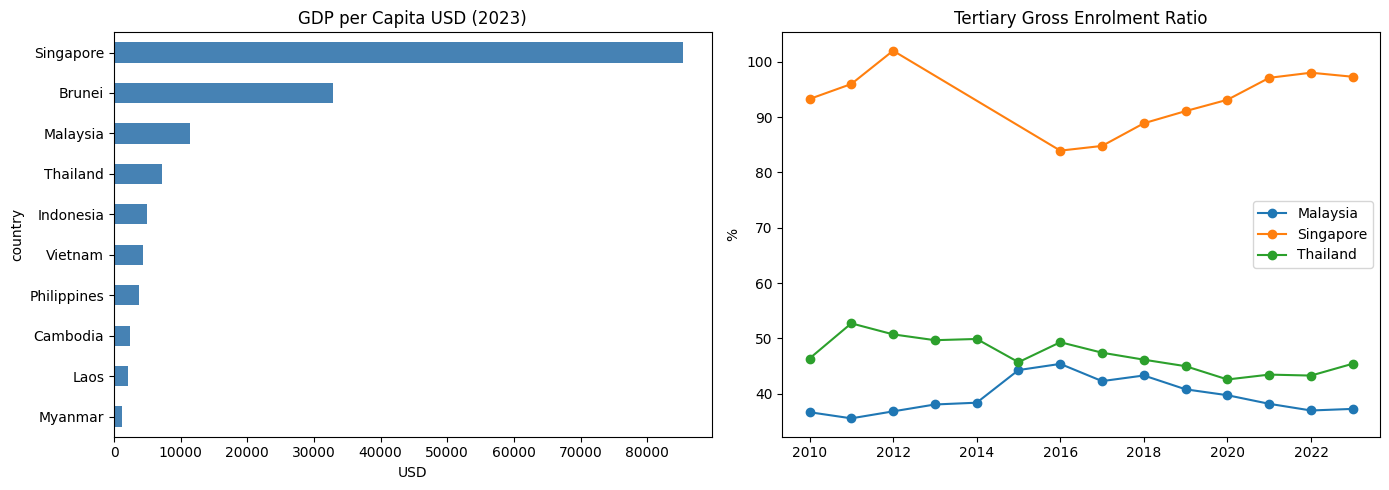

In [3]:
# Plot: GDP per capita comparison (latest available year)
latest_year = df_asean['year'].max()
df_latest = df_asean[df_asean['year'] == latest_year].dropna(subset=['gdp_per_capita_usd'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_latest.sort_values('gdp_per_capita_usd', ascending=True).plot(
    kind='barh', x='country', y='gdp_per_capita_usd',
    ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title(f'GDP per Capita USD ({latest_year})')
axes[0].set_xlabel('USD')

# Tertiary enrolment ratio for Malaysia vs region
df_mys = df_asean[df_asean['country_code'] == 'MYS'].dropna(subset=['tertiary_gross_enrolment_ratio'])
df_sgp = df_asean[df_asean['country_code'] == 'SGP'].dropna(subset=['tertiary_gross_enrolment_ratio'])
df_tha = df_asean[df_asean['country_code'] == 'THA'].dropna(subset=['tertiary_gross_enrolment_ratio'])

for df_c, label in [(df_mys, 'Malaysia'), (df_sgp, 'Singapore'), (df_tha, 'Thailand')]:
    axes[1].plot(df_c['year'], df_c['tertiary_gross_enrolment_ratio'], marker='o', label=label)
axes[1].set_title('Tertiary Gross Enrolment Ratio')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
os.makedirs('../data/asean', exist_ok=True)
df_asean.to_csv('../data/asean/asean_comparison.csv', index=False, encoding='utf-8')
print("Saved -> ../data/asean/asean_comparison.csv")
print(f"Rows exported: {len(df_asean)}")

Saved -> ../data/asean/asean_comparison.csv
Rows exported: 140
